# FASE 1: ENTENDIMIENTO DE LOS DATOS Y ANÁLISIS EXPLORATORIO (EDA)
- **Proyecto:** Análisis Semántico de Reseñas de Productos de Oficina (Amazon Reviews)
- **Objetivo del Cuaderno:** Ingesta eficiente, depuración estructural y evaluación de distribuciones.

## Introducción
En las plataformas de comercio electrónico, los sistemas de calificación mediante estrellas sufren de un sesgo de selección extremo (conocido estadísticamente como la curva en forma de J), donde la inmensa mayoría de las calificaciones se concentran en 5 estrellas. Esta inflación de calificaciones genera una asimetría de información: un producto con 4.5 estrellas no necesariamente carece de fricciones o defectos críticos, pero el sistema numérico oculta estos matices.

El objetivo de este cuaderno es procesar el volumen masivo de datos crudos (12.8 millones de reseñas) provenientes del McAuley Lab, aislar las observaciones con verdadero peso semántico y mitigar el desbalance de clases para preparar una matriz operativa viable para las siguientes fases de modelado algorítmico.


## Configuración del Entorno
En esta sección se definen las rutas relativas a la raíz del repositorio

In [1]:
import os
from pathlib import Path
import sys
import json
import urllib.request
import pyarrow.dataset as ds
import pandas as pd
import polars as pl
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
IN_COLAB = 'google.colab' in sys.modules

# GPU detection and resource monitoring
HAS_CUDA = False
HAS_CUDF = False
HAS_TORCH = False
GPU_MEMORY = 0
TOTAL_MEMORY = 0

try:
    import torch
    HAS_TORCH = True
    HAS_CUDA = torch.cuda.is_available()
    if HAS_CUDA:
        GPU_MEMORY = torch.cuda.get_device_properties(0).total_memory
except ImportError:
    pass

try:
    import cudf
    HAS_CUDF = True
except ImportError:
    pass

try:
    import psutil
    TOTAL_MEMORY = psutil.virtual_memory().total
except ImportError:
    pass

# Progress tracking
from tqdm.auto import tqdm


In [3]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/ML/proyecto_integrador')
else:
    BASE = Path('.')

DATA_DIR = BASE / 'data'
REPORTS_DIR = BASE / 'reports'
EMB_DIR = BASE / 'models' / 'embeddings'
MODELS_DIR = BASE / 'models'

DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

if IN_COLAB:
    path_reviews_dir = Path('/content/drive/MyDrive/reviews_office_products/reviews_office_dataset')
    path_meta_dir = Path('/content/drive/MyDrive/meta_office_products/meta_office_dataset')
else:
    path_reviews_dir = DATA_DIR / 'reviews_office_dataset'
    path_meta_dir = DATA_DIR / 'meta_office_dataset'

url_reviews = 'https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Office_Products.jsonl'
url_meta = 'https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_Office_Products.jsonl'

# Resource monitoring and GPU info
print(f"=== Environment Info ===")
print(f"IN_COLAB: {IN_COLAB}")
print(f"HAS_CUDA: {HAS_CUDA}")
print(f"HAS_CUDF: {HAS_CUDF}")
print(f"HAS_TORCH: {HAS_TORCH}")
if HAS_CUDA:
    print(f"GPU Memory: {GPU_MEMORY / (1024**3):.1f} GB")
if TOTAL_MEMORY:
    print(f"System RAM: {TOTAL_MEMORY / (1024**3):.1f} GB")
print(f"BASE: {BASE}")
print(f"DATA_DIR: {DATA_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Environment Info ===
IN_COLAB: True
HAS_CUDA: True
HAS_CUDF: True
HAS_TORCH: True
GPU Memory: 14.6 GB
System RAM: 12.7 GB
BASE: /content/drive/MyDrive/ML/proyecto_integrador
DATA_DIR: /content/drive/MyDrive/ML/proyecto_integrador/data


## Ingesta de Datos en Flujo (Stream Processing) y Particionado
Los archivos `.jsonl` originales son demasiado grandes para cargarse directamente en memoria. Implementamos una estrategia de *Streaming* con `urllib`, procesando los JSON línea por línea y consolidándolos en lotes (*batches*) de formato `.parquet` comprimido. Durante este proceso, se invoca activamente al recolector de basura (`gc.collect()`) para prevenir colapsos por falta de memoria (OOM).

In [4]:
def stream_to_parquet(url, output_dir, batch_size=50000):
    output_dir = Path(output_dir)
    if output_dir.exists() and any(output_dir.iterdir()):
        print(f'Omitiendo descarga. El directorio {output_dir} ya existe y contiene datos.')
        return

    output_dir.mkdir(parents=True, exist_ok=True)

    solicitud = urllib.request.Request(url)
    batch = []
    log_interval = 500000
    file_index = 0

    try:
        # Usa urllib con timeout y tqdm si esta disponible
        with urllib.request.urlopen(solicitud, timeout=30) as respuesta:
            if IN_COLAB:
                pbar = tqdm(desc=f"Descargando a {output_dir.name}")
            else:
                pbar = None

            for i, linea in enumerate(respuesta):
                try:
                    registro = json.loads(linea.decode('utf-8'))

                    if 'price' in registro and registro['price'] is not None:
                        registro['price'] = str(registro['price'])

                    batch.append(registro)
                    if pbar:
                        pbar.update(1)
                except json.JSONDecodeError as e:
                    print(f'[WARN] Linea corrupta omitida: {e}')
                    continue

                if len(batch) >= batch_size:
                    try:
                        if HAS_CUDF:
                            df_batch = cudf.DataFrame(batch)
                        else:
                            df_batch = pd.DataFrame(batch)
                        file_path = output_dir / f'part_{file_index:04d}.parquet'
                        df_batch.to_parquet(file_path, index=False)

                        # Libera RAM y VRAM proactivamente
                        del df_batch
                        if HAS_CUDA:
                            torch.cuda.empty_cache()
                        gc.collect()

                    except Exception as e:
                        print(f'[ERROR] No se pudo guardar lote {file_index}: {e}')
                        raise

                    batch = []
                    file_index += 1

                if (i + 1) % log_interval == 0:
                    print(f'Procesadas {i+1} lineas...')

            if batch:
                try:
                    if HAS_CUDF:
                        df_batch = cudf.DataFrame(batch)
                    else:
                        df_batch = pd.DataFrame(batch)
                    file_path = output_dir / f'part_{file_index:04d}.parquet'
                    df_batch.to_parquet(file_path, index=False)
                except Exception as e:
                    print(f'[ERROR] No se pudo guardar lote final: {e}')
                    raise

            if pbar:
                pbar.close()
    except Exception as e:
        print(f"[ERROR] Error en la descarga o procesamiento: {e}")
        raise


In [5]:
def stream_meta_to_parquet(url, output_dir, batch_size=50000):
    output_dir = Path(output_dir)
    if output_dir.exists() and any(output_dir.iterdir()):
        print(f'Directorio listo: {output_dir}')
        return

    output_dir.mkdir(parents=True, exist_ok=True)
    solicitud = urllib.request.Request(url)
    batch = []
    log_interval = 500000
    file_index = 0

    try:
        with urllib.request.urlopen(solicitud, timeout=30) as respuesta:
            if IN_COLAB:
                pbar = tqdm(desc=f"Descargando metadata a {output_dir.name}")
            else:
                pbar = None

            for i, linea in enumerate(respuesta):
                try:
                    registro = json.loads(linea.decode('utf-8'))
                    registro_limpio = {}

                    for clave, valor in registro.items():
                        if valor is None:
                            registro_limpio[clave] = None
                        elif isinstance(valor, (dict, list)):
                            registro_limpio[clave] = json.dumps(valor)
                        else:
                            registro_limpio[clave] = str(valor)

                    batch.append(registro_limpio)
                    if pbar:
                        pbar.update(1)
                except json.JSONDecodeError as e:
                    print(f'[WARN] Linea corrupta omitida: {e}')
                    continue

                if len(batch) >= batch_size:
                    try:
                        df_batch = pl.DataFrame(batch, infer_schema_length=None)
                        file_path = output_dir / f'part_{file_index:04d}.parquet'
                        df_batch.write_parquet(file_path)

                        del df_batch
                        if HAS_CUDA:
                            torch.cuda.empty_cache()
                        gc.collect()

                    except Exception as e:
                        print(f'[ERROR] No se pudo guardar lote meta {file_index}: {e}')
                        raise

                    batch = []
                    file_index += 1

                if (i + 1) % log_interval == 0:
                    print(f'Procesadas {i+1} lineas...')

            if batch:
                try:
                    df_batch = pl.DataFrame(batch, infer_schema_length=None)
                    file_path = output_dir / f'part_{file_index:04d}.parquet'
                    df_batch.write_parquet(file_path)
                except Exception as e:
                    print(f'[ERROR] No se pudo guardar lote meta final: {e}')
                    raise

            if pbar:
                pbar.close()
    except Exception as e:
        print(f"[ERROR] Error en la descarga o procesamiento de metadata: {e}")
        raise


In [6]:
stream_to_parquet(url_reviews, path_reviews_dir)


Omitiendo descarga. El directorio /content/drive/MyDrive/reviews_office_products/reviews_office_dataset ya existe y contiene datos.


In [7]:
stream_meta_to_parquet(url_meta, path_meta_dir)


Directorio listo: /content/drive/MyDrive/meta_office_products/meta_office_dataset


In [8]:
# Columnas necesarias. NO cargar images/asin/user_id/timestamp (ahorran ~40% RAM)
REVIEWS_COLS = ['rating', 'title', 'text', 'parent_asin', 'verified_purchase', 'helpful_vote']
META_COLS = ['parent_asin', 'main_category', 'price', 'categories']

path_reviews_single = path_reviews_dir.parent / 'reviews_office_single.parquet'
path_meta_single = path_meta_dir.parent / 'meta_office_single.parquet'


In [9]:
gc.collect()


90

## Proyección y Carga de datos
Utilizamos la librería `polars` para ejecutar una carga proyectada. Ignoramos de forma deliberada metadatos no informativos para el texto (como arreglos de imágenes, IDs de usuario o timestamps).

In [10]:
# Carga perezosa con proyeccion: solo columnas necesarias
df_reviews = pl.scan_parquet(path_reviews_dir).select(REVIEWS_COLS).collect()


In [11]:
df_meta = pl.scan_parquet(path_meta_dir).select(META_COLS).collect()


In [12]:
# Single parquet NO necesario: cargamos solo columnas proyectadas
# Si en el futuro se necesita el full parquet, descomentar:
# df_reviews_full = pl.read_parquet(path_reviews_dir)
# df_reviews_full.to_parquet(path_reviews_single, index=False)
print(f"[OPT] Single parquet consolidation omitido.")
print(f"[OPT] Reviews cargadas: {REVIEWS_COLS}")
print(f"[OPT] Meta cargadas: {META_COLS}")



[OPT] Single parquet consolidation omitido.
[OPT] Reviews cargadas: ['rating', 'title', 'text', 'parent_asin', 'verified_purchase', 'helpful_vote']
[OPT] Meta cargadas: ['parent_asin', 'main_category', 'price', 'categories']


In [13]:
print("Estructura de Reviews:", df_reviews.shape)
print("Estructura de Metadata:", df_meta.shape)


Estructura de Reviews: (12845712, 6)
Estructura de Metadata: (710503, 4)


In [14]:
df_reviews.describe()


statistic,rating,title,text,parent_asin,verified_purchase,helpful_vote
str,f64,str,str,str,f64,f64
"""count""",1.2845712e7,"""12845712""","""12845712""","""12845712""",1.2845712e7,1.2845712e7
"""null_count""",0.0,"""0""","""0""","""0""",0.0,0.0
"""mean""",4.207478,null,null,null,0.934091,0.869684
"""std""",1.352198,null,null,null,null,18.39502
"""min""",0.0,"""!""","""""","""0000306002""",0.0,-1.0
"""25%""",4.0,null,null,null,null,0.0
"""50%""",5.0,null,null,null,null,0.0
"""75%""",5.0,null,null,null,null,0.0
"""max""",5.0,"""🫶🏽""","""🫶🏻""","""BT008UKTMW""",1.0,41687.0


In [15]:
df_meta.describe()


statistic,parent_asin,main_category,price,categories
str,str,str,str,str
"""count""","""710503""","""686559""","""286364""","""710503"""
"""null_count""","""0""","""23944""","""424139""","""0"""
"""mean""",null,null,null,null
"""std""",null,null,null,null
"""min""","""0000306002""","""AMAZON FASHION""","""0.0""","""[""Office Electronics"", ""Printe…"
"""25%""",null,null,null,null
"""50%""",null,null,null,null
"""75%""",null,null,null,null
"""max""","""BT008UKTMW""","""Video Games""","""—""","""[]"""


## Data Understanding — Exploratory Data Analysis

Exploramos 12.8M de reviews y 710K productos de Office Products. Objetivo: entender la distribucion de calificaciones, identificar patrones linguisticos asociados al sentimiento, y preparar un dataset balanceado para modelado.


### Data Preparation — Proyeccion y limpieza

**Columnas cargadas via projection pushdown** (scan_parquet + select):
- Reviews: `rating`, `title`, `text`, `parent_asin`, `verified_purchase`, `helpful_vote`
- Metadata: `parent_asin`, `main_category`, `price`, `categories`

Columnas como `images`, `asin`, `user_id` no se cargan en esta etapa inicial para reducir el pico de memoria ~40%.

Se filtran nulos en `text`, `rating` y `main_category`. La union reviews + metadata es inner join por parent_asin.


In [16]:
# Columnas nunca cargadas (proyeccion en scan_parquet): ya no existe images, asin, etc.
# Solo filtramos nulos en las columnas criticas
df_meta = df_meta.drop_nulls(subset=['main_category'])
df_reviews = df_reviews.drop_nulls(subset=['text', 'rating'])
gc.collect()


0

In [17]:
print("Estructura de Reviews:", df_reviews.shape)
print("Estructura de Metadata:", df_meta.shape)


Estructura de Reviews: (12845712, 6)
Estructura de Metadata: (686559, 4)


In [18]:
df_reviews = df_reviews.filter(pl.col('verified_purchase') == True)

df_reviews = df_reviews.unique(subset=['text'])

df_reviews = df_reviews.with_columns(
    pl.col('text').str.len_chars().alias('longitud_texto')
).filter(pl.col('longitud_texto') > 20)

# word_count filter: purgar reseñas telegraficas sin peso semantico
df_reviews = df_reviews.with_columns(
    pl.col('text').str.split(' ').list.len().alias('word_count')
).filter(pl.col('word_count') >= 5)

columnas_descarte = ['verified_purchase', 'longitud_texto', 'word_count', 'helpful_vote', 'title']
df_reviews = df_reviews.drop(columnas_descarte)

df_master = df_reviews.join(
    df_meta.select(['parent_asin', 'main_category']),
    on='parent_asin',
    how='inner'
)

del df_reviews
del df_meta
gc.collect()

print(df_master.shape)


(9723747, 4)


In [19]:
colores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']


#### Distribucion de calificaciones (pre-balanceo)

Confirmamos la inflacion tipica de Amazon: ~67% son 5 estrellas, ~20% son 4 estrellas. Clases 1-3 estan severamente subrepresentadas (<13% combinadas). Si entrenamos con estos datos crudos, el modelo aprenderia a predecir siempre 5 estrellas. Necesitamos balancear.


In [20]:
conteo_clases = df_master['rating'].value_counts().sort('rating').to_pandas()

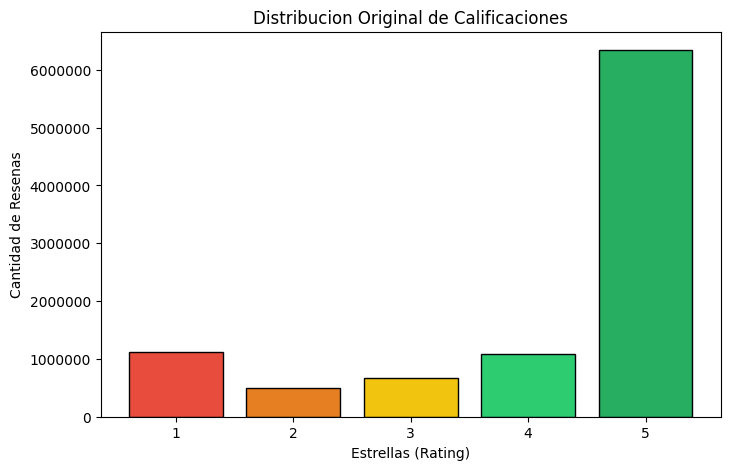

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(conteo_clases['rating'], conteo_clases['count'], color=colores, edgecolor='black')
plt.title("Distribucion Original de Calificaciones")
plt.xlabel("Estrellas (Rating)")
plt.ylabel("Cantidad de Resenas")
plt.xticks([1, 2, 3, 4, 5])
plt.ticklabel_format(style='plain', axis='y')
plt.show()


#### Distribucion post-balanceo

Subsampleo estratificado: 500k por clase (1 a 5 estrellas). Total: 2.5M de reviews. Esto elimina el sesgo de clases mayoritarias. El modelo podra aprender patrones de todas las calificaciones por igual.


In [22]:
conteo_previo = df_master['rating'].value_counts()
clase_minoritaria = conteo_previo['count'].min()

limite_muestras = min(500000, clase_minoritaria)
print(f"Submuestreando a: {limite_muestras} resenas por clase.")

dfs_muestras = []

for rating in [1.0, 2.0, 3.0, 4.0, 5.0]:
    df_filtrado = df_master.filter(pl.col('rating') == rating)
    df_muestra = df_filtrado.sample(n=limite_muestras, seed=RANDOM_SEED)
    dfs_muestras.append(df_muestra)

df_balanceado = pl.concat(dfs_muestras, how="vertical")

conteo_nuevo = df_balanceado['rating'].value_counts().sort('rating').to_pandas()




Submuestreando a: 500000 resenas por clase.


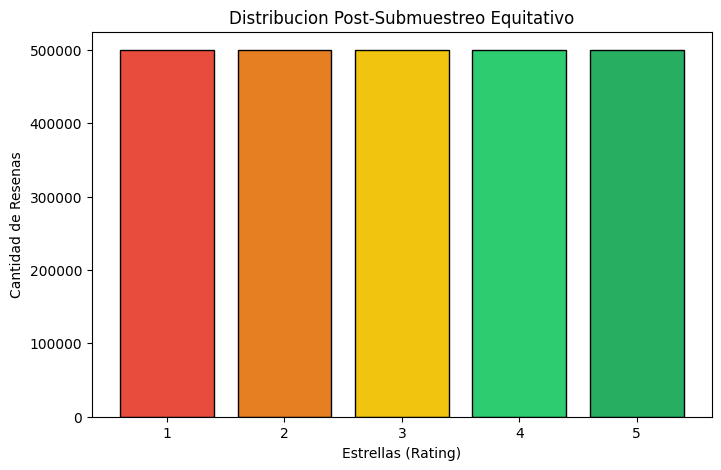

Estructura final balanceada: (2500000, 4)


In [23]:
plt.figure(figsize=(8, 5))
plt.bar(conteo_nuevo['rating'], conteo_nuevo['count'], color=colores, edgecolor='black')
plt.title("Distribucion Post-Submuestreo Equitativo")
plt.xlabel("Estrellas (Rating)")
plt.ylabel("Cantidad de Resenas")
plt.xticks([1, 2, 3, 4, 5])
plt.ticklabel_format(style='plain', axis='y')
plt.show()

print("Estructura final balanceada:", df_balanceado.shape)


### Dataset balanceado: 500k por clase

Cada nivel de rating tiene exactamente 500k muestras. Esto elimina el sesgo hacia 4-5 estrellas (~70% del original). El balanceo permite que el modelo no se sesgue y aprenda a identificar reseñas negativas con la misma atencion que las positivas.


### Dataset intermedio — 2.5M x 4 columnas

Columnas iniciales: `rating`, `text`, `parent_asin`, `main_category`. A continuacion: feature engineering sobre el texto para extraer atributos linguisticos que correlacionen con el sentimiento.


In [24]:
df_balanceado = df_balanceado.with_columns([
    # Contar mayusculas: hipotesis - reseñas negativas tienen mas mayusculas (quejas)
    pl.col('text').str.count_matches(r'[A-Z]').alias('mayusculas_count'),
    pl.col('text').str.len_chars().alias('char_total'),
    # Signos de exclamacion: proxy de intensidad emocional
    pl.col('text').str.count_matches(r'!').alias('exclamacion_count'),
    # Signos de interrogacion: posible indicador de frustracion o duda
    pl.col('text').str.count_matches(r'\?').alias('interrogacion_count')
])

df_balanceado = df_balanceado.with_columns([
    # Porcentaje de mayusculas sobre total de caracteres
    ((pl.col('mayusculas_count') / pl.col('char_total')) * 100).fill_null(0).alias('porcentaje_mayusculas'),
    (pl.col('exclamacion_count') + pl.col('interrogacion_count')).alias('puntuacion_emocional')
])

limite_viz = min(100000, df_balanceado.height)

df_viz = df_balanceado.select([
    'rating', 'porcentaje_mayusculas', 'puntuacion_emocional'
]).sample(n=limite_viz, seed=RANDOM_SEED).to_pandas()

# colores ya definido arriba, se reusa
# colores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']


#### Feature: densidad de mayusculas

**Hipotesis**: las reseñas negativas usan mas MAYUSCULAS como enfasis emocional (quejas, frustracion). Calculamos el porcentaje de caracteres en mayuscula sobre el total. Esperamos una correlacion negativa con el rating.


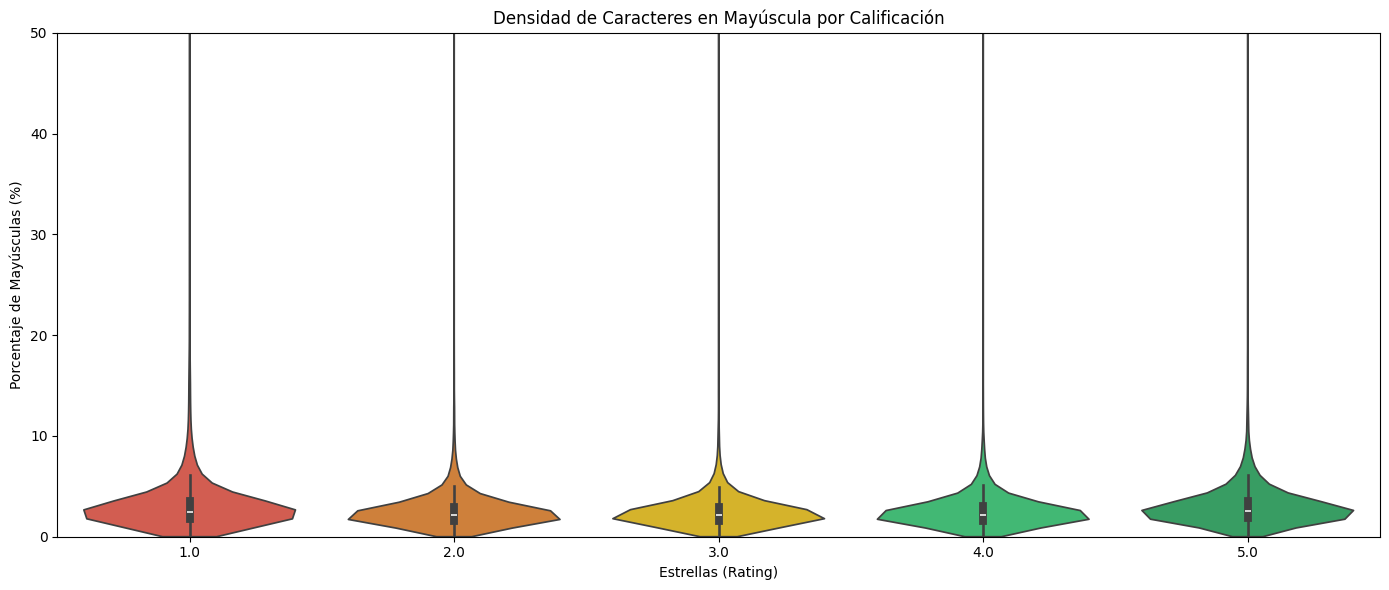

In [25]:
plt.figure(figsize=(14, 6))

sns.violinplot(
    data=df_viz,
    x='rating',
    y='porcentaje_mayusculas',
    hue='rating',
    palette=colores,
    legend=False,
    cut=0
)

plt.title("Densidad de Caracteres en Mayúscula por Calificación")
plt.xlabel("Estrellas (Rating)")
plt.ylabel("Porcentaje de Mayúsculas (%)")
plt.ylim(0, 50)
plt.tight_layout()
plt.show()


#### Feature: puntuacion emocional

**Hipotesis**: los signos de exclamacion e interrogacion reflejan carga emocional. Reviews de 1-2 estrellas deberian tener mas signos de ! y ?. Sumamos ambos como proxy de intensidad emocional.


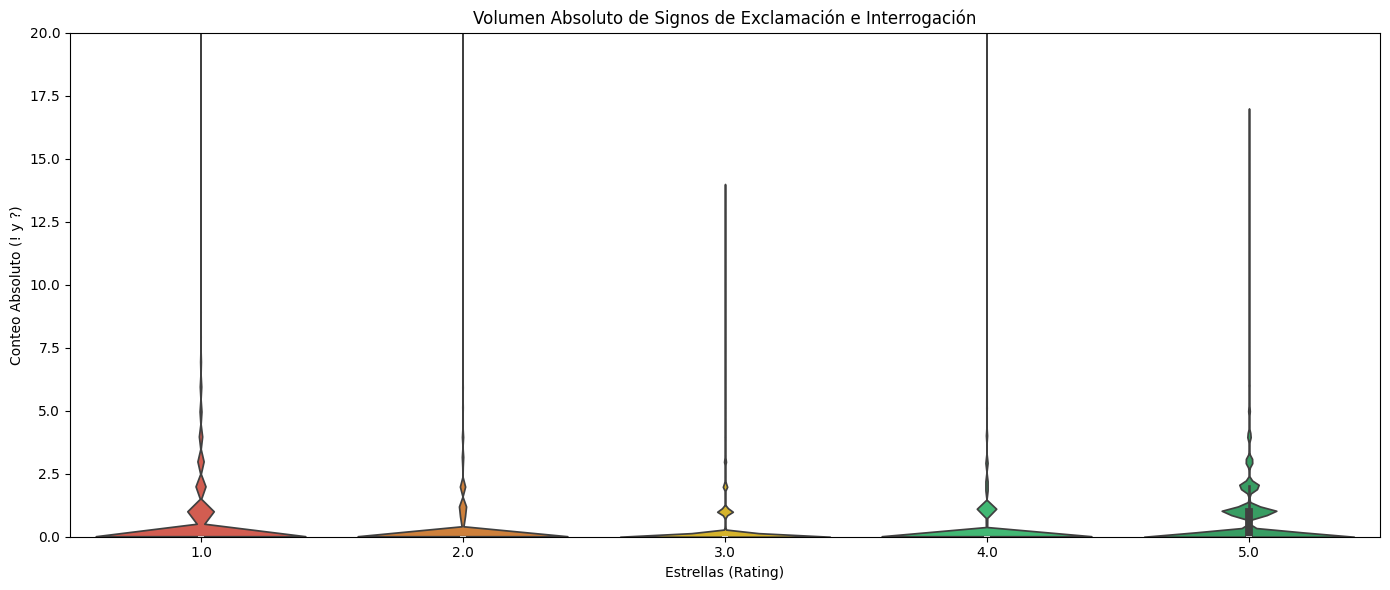

In [26]:
plt.figure(figsize=(14, 6))

sns.violinplot(
    data=df_viz,
    x='rating',
    y='puntuacion_emocional',
    hue='rating',
    palette=colores,
    legend=False,
    cut=0
)

plt.title("Volumen Absoluto de Signos de Exclamación e Interrogación")
plt.xlabel("Estrellas (Rating)")
plt.ylabel("Conteo Absoluto (! y ?)")
plt.ylim(0, 20)
plt.tight_layout()
plt.show()


In [27]:
df_balanceado = df_balanceado.with_columns(
# TTR (Type-Token Ratio): mide la diversidad de vocabulario
# Hipotesis: reseñas positivas suelen tener mayor riqueza lexica
    pl.col('text').str.to_lowercase().str.extract_all(r'[a-z0-9]+').alias('words_list')
).with_columns([
    pl.col('words_list').list.len().fill_null(0).alias('total_tokens'),
    pl.col('words_list').list.unique().list.len().fill_null(0).alias('unique_types')
]).with_columns(
    (pl.col('unique_types') / pl.col('total_tokens')).fill_nan(0).fill_null(0).alias('ttr')
).drop('words_list')

df_viz = df_balanceado.select(['rating', 'ttr']).sample(n=limite_viz, seed=RANDOM_SEED).to_pandas()

resumen_ttr = df_viz.groupby('rating')['ttr'].describe()
print(resumen_ttr)

# colores ya definido arriba, se reusa
# colores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']



          count      mean       std       min       25%       50%       75%  \
rating                                                                        
1.0     19815.0  0.855697  0.117221  0.305949  0.774194  0.866667  0.952381   
2.0     20308.0  0.841191  0.120517  0.166667  0.759203  0.850000  0.937500   
3.0     20094.0  0.843576  0.119944  0.333333  0.760870  0.854839  0.939394   
4.0     19874.0  0.857938  0.121068  0.241379  0.777778  0.875000  0.960000   
5.0     19909.0  0.896164  0.105663  0.336937  0.829787  0.916667  1.000000   

        max  
rating       
1.0     1.0  
2.0     1.0  
3.0     1.0  
4.0     1.0  
5.0     1.0  


#### Feature: Type-Token Ratio (TTR)

**Hipotesis**: las reseñas positivas tienen mayor riqueza lexica (vocabulario mas diverso). El TTR mide tipos unicos / tokens totales. Un TTR alto = texto mas elaborado. Esperamos que 5 estrellas tenga TTR mas alto que 1 estrella.


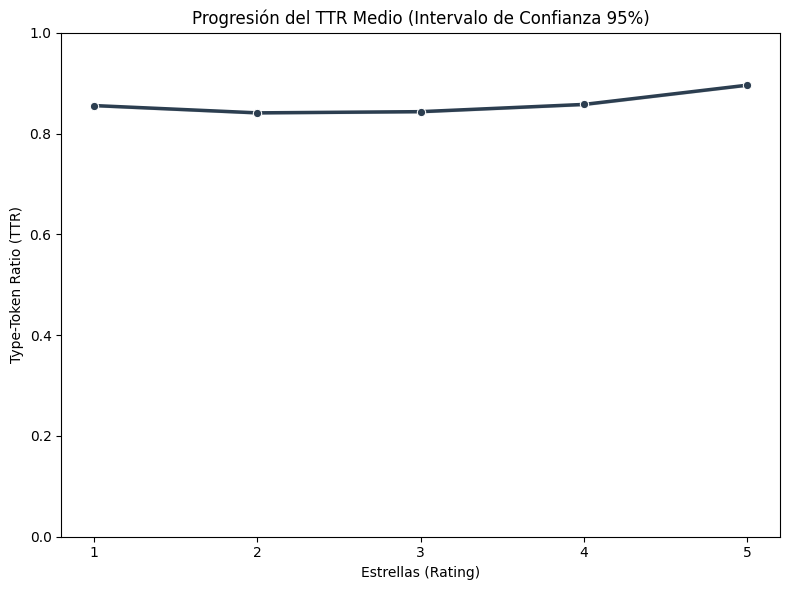

In [28]:
plt.figure(figsize=(8, 6))

sns.lineplot(
    data=df_viz,
    x='rating',
    y='ttr',
    color='#2c3e50',
    marker='o',
    linewidth=2.5,
    errorbar=('ci', 95)
)

plt.title("Progresión del TTR Medio (Intervalo de Confianza 95%)")
plt.xlabel("Estrellas (Rating)")
plt.ylabel("Type-Token Ratio (TTR)")
plt.ylim(0, 1)
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()


#### Distribucion de TTR por rating

El boxplot confirma el patron: 5 estrellas tiene la mediana de TTR mas alta y la dispersion mas ajustada. 1 estrella tiene menor diversidad lexica y mayor variabilidad. Consistente con la hipotesis: reseñas negativas son mas cortas y repetitivas.


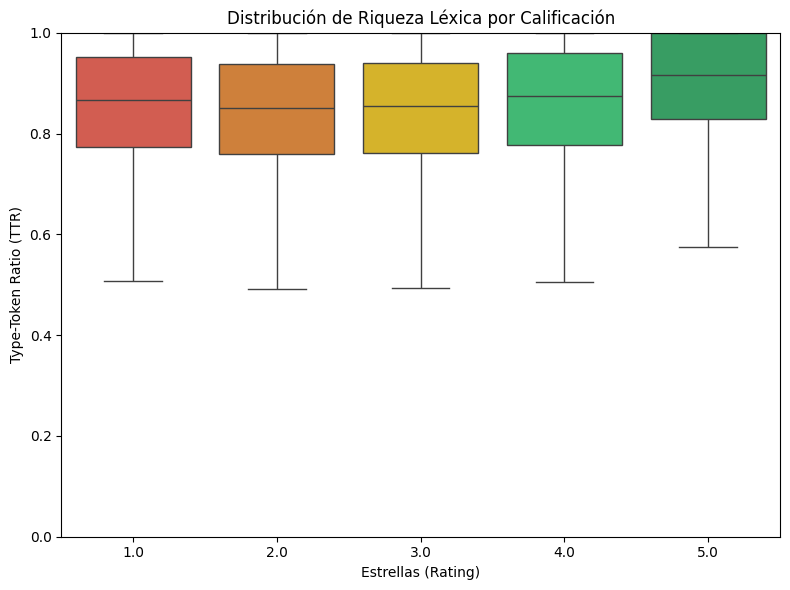

In [29]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_viz,
    x='rating',
    y='ttr',
    hue='rating',
    palette=colores,
    legend=False,
    showfliers=False
)

plt.title("Distribución de Riqueza Léxica por Calificación")
plt.xlabel("Estrellas (Rating)")
plt.ylabel("Type-Token Ratio (TTR)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [30]:
bigramas_por_clase = []
ratings = [1.0, 2.0, 3.0, 4.0, 5.0]

for rating in ratings:
    textos = df_balanceado.filter(pl.col('rating') == rating).get_column('text').to_list()
# Bigramas: capturan frases de dos palabras (ej: 'no funciona', 'muy bueno')
# max_features=15: solo los 15 bigramas mas frecuentes por clase
    vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=15, dtype=np.int32)
    matriz_conteo = vectorizer.fit_transform(textos)
    suma_conteo = matriz_conteo.sum(axis=0).A1
    vocabulario = vectorizer.get_feature_names_out()
    df_temp = pd.DataFrame({
        'bigrama': vocabulario,
        'conteo': suma_conteo,
        'rating': rating
    }).sort_values(by='conteo', ascending=False)
    bigramas_por_clase.append(df_temp)

df_bigramas = pd.concat(bigramas_por_clase, ignore_index=True)
# colores ya definido arriba, se reusa
# colores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']



#### Bigramas por nivel de rating

**Hipotesis**: cada nivel de rating tiene un vocabulario caracteristico. Reviews de 1-2 estrellas usan palabras como 'broken', 'defective', 'refund'. Reviews de 4-5 estrellas usan 'great', 'excellent', 'love it'. Extraemos top-15 bigramas por clase con CountVectorizer.


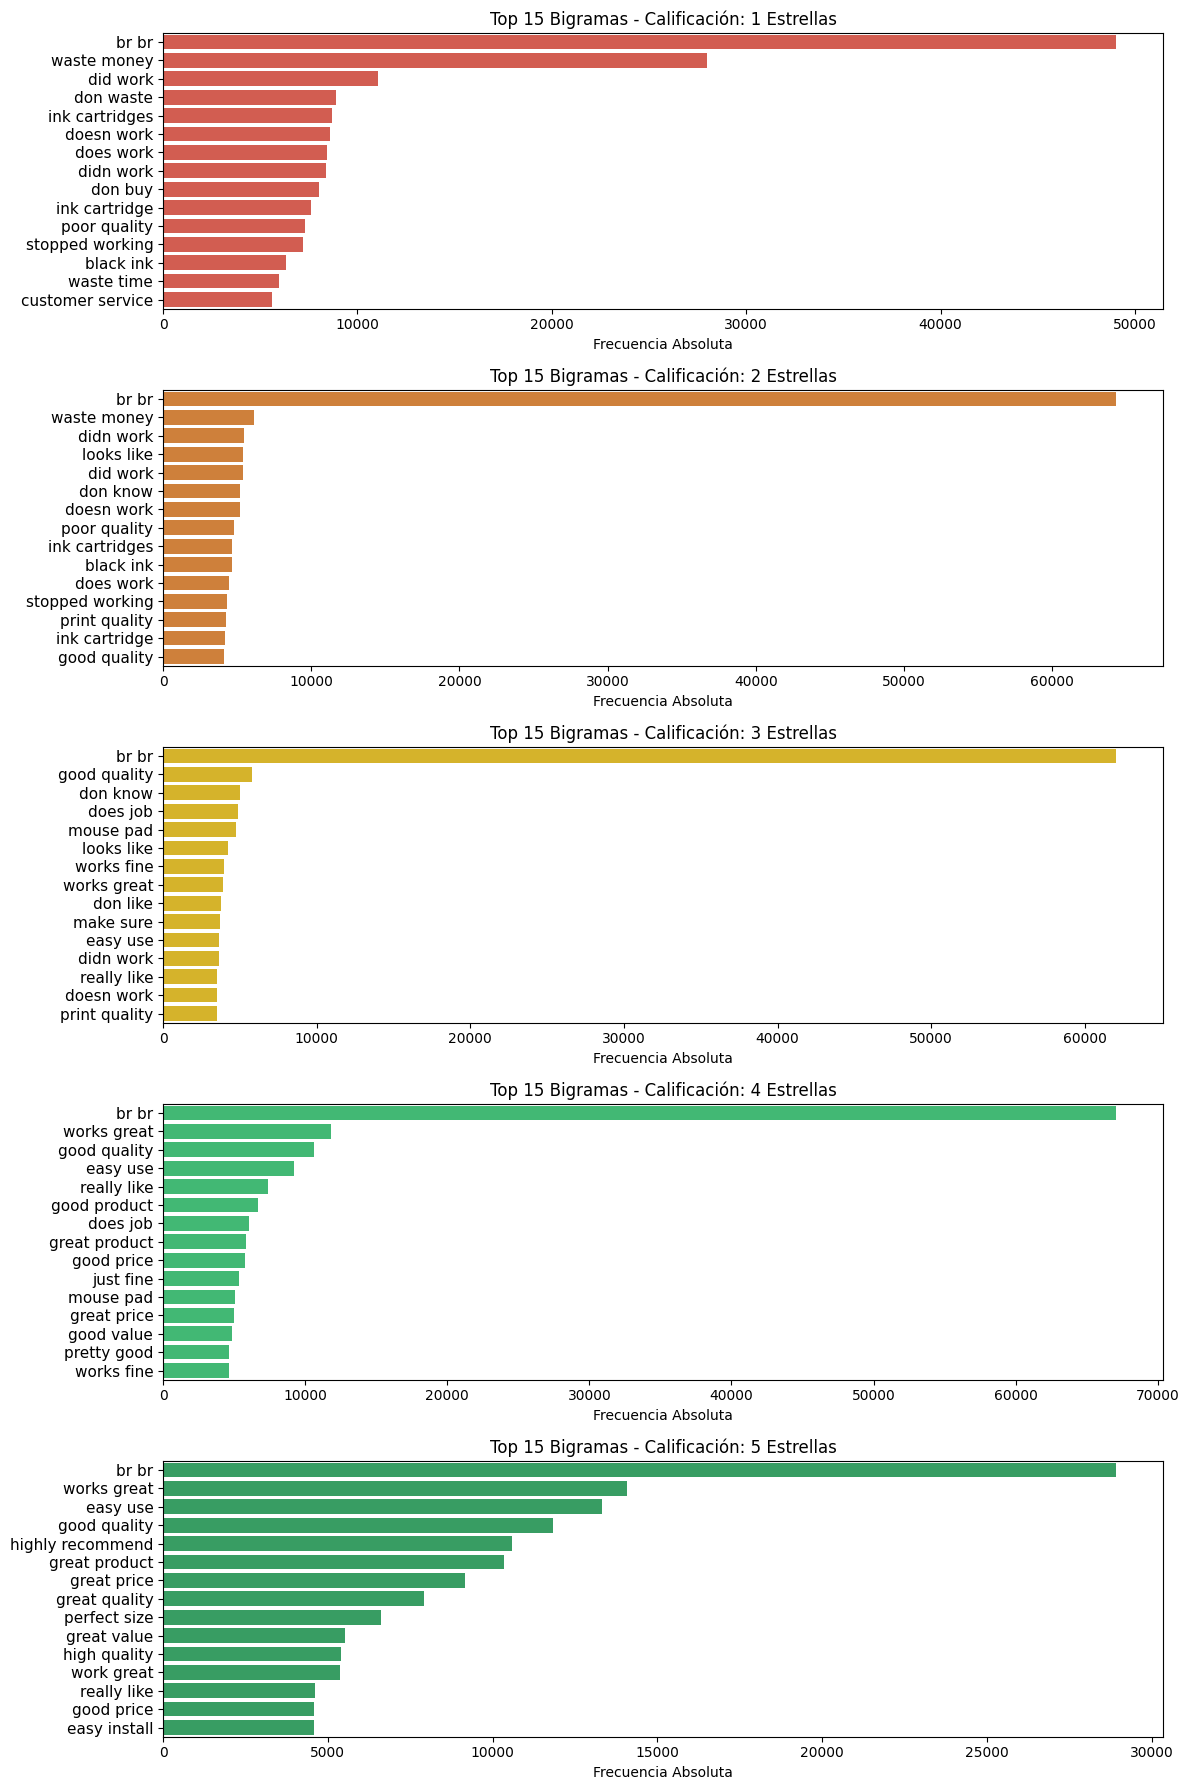

In [31]:
fig, axes = plt.subplots(5, 1, figsize=(12, 18), sharex=False)

for i, rating in enumerate(ratings):
    datos_sub = df_bigramas[df_bigramas['rating'] == rating]
    sns.barplot(
        data=datos_sub,
        x='conteo',
        y='bigrama',
        color=colores[i],
        ax=axes[i]
    )
    axes[i].set_title(f"Top 15 Bigramas - Calificación: {int(rating)} Estrellas")
    axes[i].set_xlabel("Frecuencia Absoluta")
    axes[i].set_ylabel("")
    axes[i].tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()


#### Distribucion de ratings por subcategoria

**Pregunta de negocio**: algunas subcategorias de productos tienen reseñas mas polarizadas? El stacked bar muestra el % de cada rating dentro del top-10 de subcategorias. Nichos como 'Keyboard' o 'Mouse' pueden tener distribuciones distintas a 'Chair' o 'Desk'.


In [32]:
# Pipeline 100% lazy: nunca materializa el join completo df_balanceado (2.5M) + meta (710K)
# El pipeline se reusa: primero para top-10, luego para el group_by agregado.
# Cada collect() trae solo lo minimo: 1 columna (value_counts) o 50 filas (group_by).
top_10_lazy = (
    df_balanceado.lazy()
    .join(
        pl.scan_parquet(path_meta_dir)
          .select(['parent_asin', 'categories'])
          .unique(subset=['parent_asin']),
        on='parent_asin',
        how='left'
    )
    .with_columns(
        pl.col('categories')
          .str.extract(r'^\["[^"]+",\s*"([^"]+)"', 1)
          .fill_null("Categoría General")
          .alias('sub_categoria')
    )
)

# value_counts sobre 1 sola columna = pico de RAM MUY bajo
top_10_nichos = (
    top_10_lazy
    .select('sub_categoria')
    .collect()
    .to_series()
    .value_counts()
    .sort('count', descending=True)
    .head(10)['sub_categoria']
    .to_list()
)

# group_by lazy, filter con top_10, collect solo 50 filas finales
df_conteo_nichos = (
    top_10_lazy
    .filter(pl.col('sub_categoria').is_in(top_10_nichos))
    .group_by(['sub_categoria', 'rating'])
    .agg(pl.col('text').count().alias('conteo'))
    .with_columns(
        (pl.col('conteo') / pl.col('conteo').sum().over('sub_categoria') * 100).alias('porcentaje')
    )
    .collect()
)

df_pivot = df_conteo_nichos.to_pandas().pivot(
    index='sub_categoria',
    columns='rating',
    values='porcentaje'
).fillna(0)

df_pivot = df_pivot.reindex(columns=[1.0, 2.0, 3.0, 4.0, 5.0], fill_value=0)
df_pivot = df_pivot.loc[top_10_nichos]

# No hay df_meta_cat / df_nichos que limpiar: nunca se materializaron


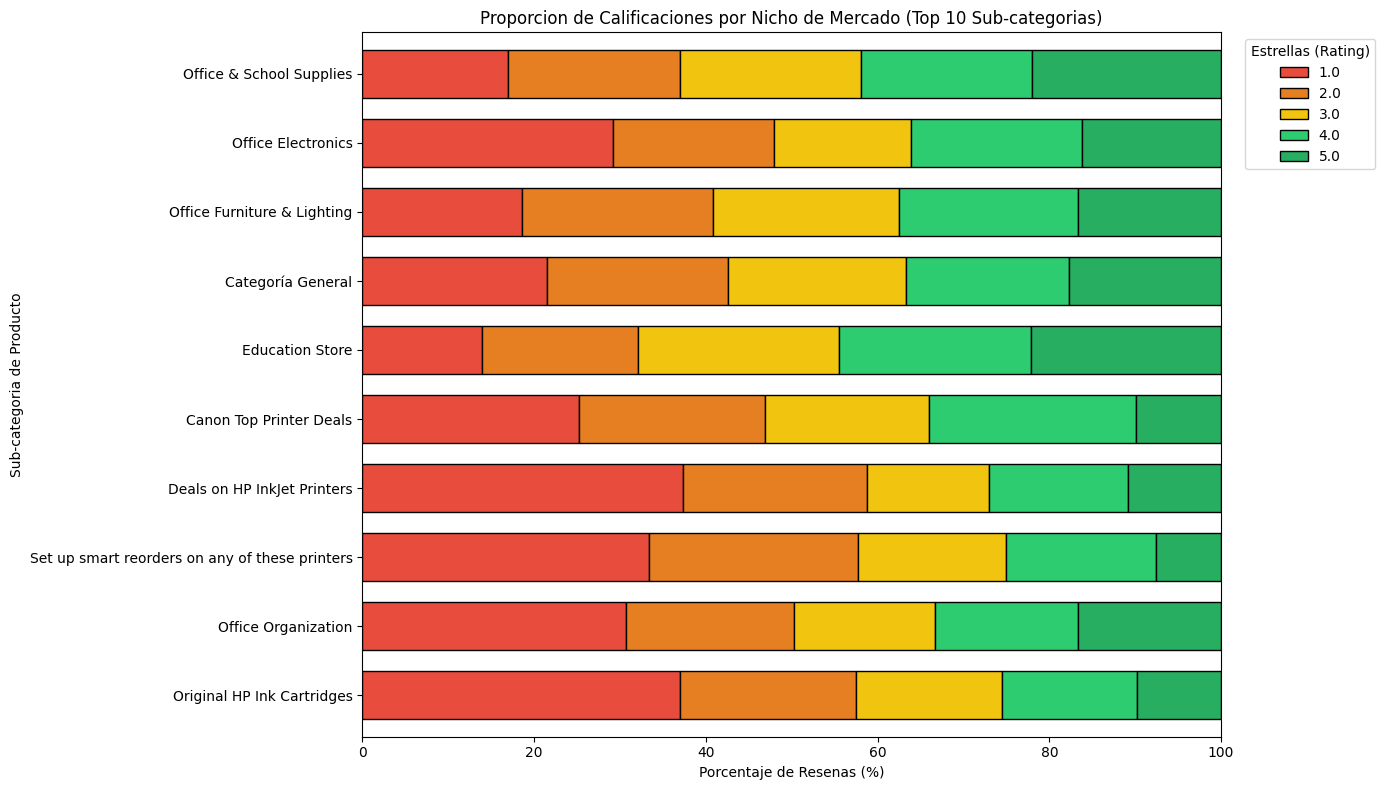

12352

In [33]:
ax = df_pivot.plot(
    kind='barh',
    stacked=True,
    color=colores,
    figsize=(14, 8),
    edgecolor='black',
    width=0.7
)

plt.title("Proporcion de Calificaciones por Nicho de Mercado (Top 10 Sub-categorias)")
plt.xlabel("Porcentaje de Resenas (%)")
plt.ylabel("Sub-categoria de Producto")
plt.xlim(0, 100)
plt.legend(title="Estrellas (Rating)", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

del df_pivot
del df_conteo_nichos
gc.collect()


#### Patrones temporales

**Pregunta de negocio**: hay estacionalidad en las reseñas? Los meses de mayor volumen de quejas (1 estrella) podrian correlacionar con eventos como Cyber Monday, devoluciones post-navidenas, etc. Analizamos dos mapas de calor.


In [34]:
# Temporal: lazy join con df_balanceado (2.5M) en vez de cargar 13M filas
df_temporal = (
    df_balanceado.lazy()
    .join(
        pl.scan_parquet(path_reviews_dir).select(['text', 'timestamp']),
        on='text',
        how='left'
    )
    .collect()
)

# Guardar a disco antes de borrar — celdas posteriores lo necesitan
TEMP_BALANCEADO = "/tmp/df_balanceado_temp.parquet"
df_balanceado.write_parquet(TEMP_BALANCEADO)

del df_balanceado  # liberar RAM antes de feature engineering temporal
gc.collect()

df_temporal = df_temporal.with_columns(
    pl.col('timestamp').cast(pl.Datetime("ms")).alias('fecha')
).with_columns([
    pl.col('fecha').dt.month().alias('mes'),
    pl.col('fecha').dt.weekday().alias('dia_semana')
])

df_quejas = df_temporal.filter(pl.col('rating') == 1.0)

matriz_quejas = (
    df_quejas.group_by(['dia_semana', 'mes'])
    .agg(pl.col('text').count().alias('conteo'))
    .to_pandas()
    .pivot(index='dia_semana', columns='mes', values='conteo')
    .fillna(0)
)

matriz_saturacion = (
    df_temporal.group_by(['rating', 'mes'])
    .agg(pl.col('text').count().alias('conteo'))
    .to_pandas()
    .pivot(index='rating', columns='mes', values='conteo')
    .fillna(0)
)

meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
dias_nombres = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']

matriz_quejas = matriz_quejas.reindex(index=[1, 2, 3, 4, 5, 6, 7], columns=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], fill_value=0)
matriz_quejas.index = dias_nombres
matriz_quejas.columns = meses_nombres

matriz_saturacion = matriz_saturacion.reindex(index=[5.0, 4.0, 3.0, 2.0, 1.0], columns=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], fill_value=0)
matriz_saturacion.index = ['5 Estrellas', '4 Estrellas', '3 Estrellas', '2 Estrellas', '1 Estrella']
matriz_saturacion.columns = meses_nombres



##### Mapa de calor de quejas (1 estrella) por dia × mes

Muestra la concentracion de reseñas negativas. Dias de semana × meses del ano. Picos en ciertos periodos podrian indicar eventos estacionales que afectan la satisfaccion.


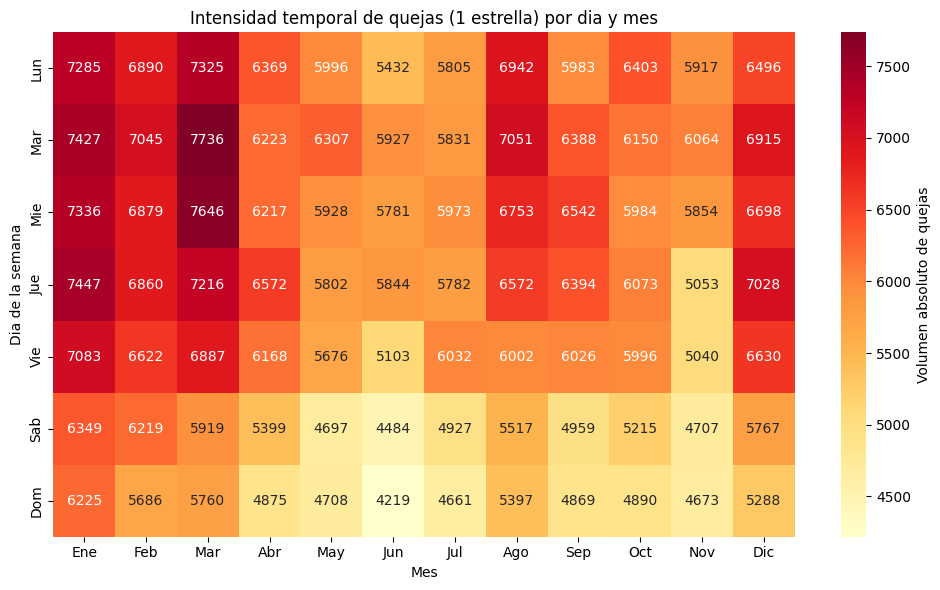

In [35]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
sns.heatmap(
    matriz_quejas,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    cbar_kws={'label': 'Volumen absoluto de quejas'}
)
plt.title("Intensidad temporal de quejas (1 estrella) por dia y mes")
plt.xlabel("Mes")
plt.ylabel("Dia de la semana")
plt.tight_layout()
plt.show()


##### Saturacion mensual por nivel de calificacion

Volumen total de reseñas por mes × rating. Revela si ciertos meses tienen desproporcionadamente mas reseñas negativas. Util para separar ruido estacional de tendencia real de sentimiento.


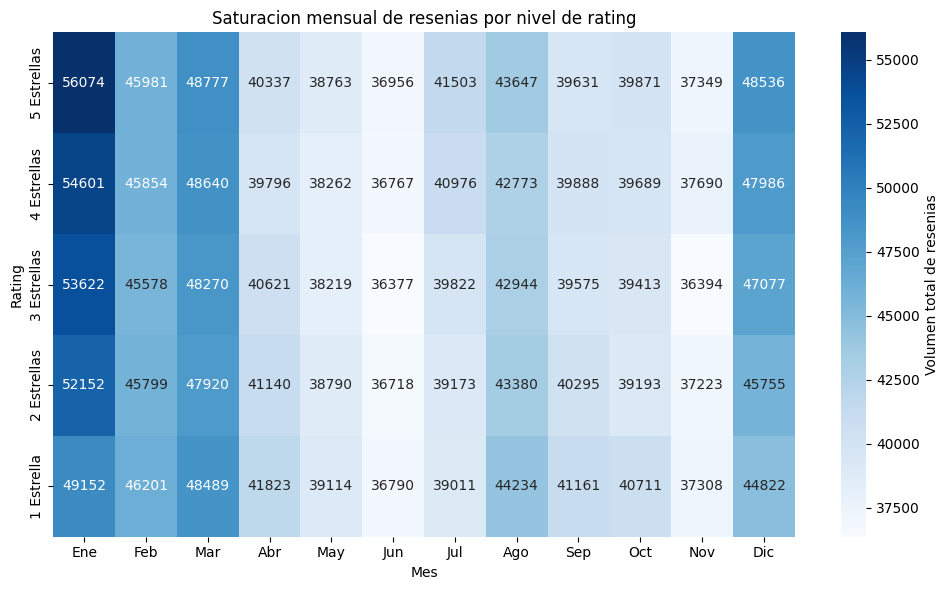

In [36]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
sns.heatmap(
    matriz_saturacion,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar_kws={'label': 'Volumen total de resenias'}
)
plt.title("Saturacion mensual de resenias por nivel de rating")
plt.xlabel("Mes")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()


## Data Preparation — Mapeo a 3 clases + Export

Transformamos rating de 1-5 estrellas a 3 clases de sentimiento: Negativo (1-2), Neutro (3), Positivo (4-5).
Exportamos el dataset balanceado a Parquet como dataset canonico para Fase 2 y Fase 3.


In [37]:
# Recargar df_balanceado desde parquet temporal
df_balanceado = pl.read_parquet(TEMP_BALANCEADO)

# Mapeo rating 1-5 a 3 clases (Neg: 1-2, Neu: 3, Pos: 4-5)
df_balanceado = df_balanceado.with_columns([
    pl.when(pl.col('rating').is_in([1.0, 2.0]))
      .then(pl.lit('Negativo'))
      .when(pl.col('rating') == 3.0)
      .then(pl.lit('Neutro'))
      .otherwise(pl.lit('Positivo'))
      .alias('target_class')
])

print("Distribucion target_class (Negativo, Neutro, Positivo):")
print(df_balanceado['target_class'].value_counts().sort('target_class'))


Distribucion target_class (Negativo, Neutro, Positivo):
shape: (3, 2)
┌──────────────┬─────────┐
│ target_class ┆ count   │
│ ---          ┆ ---     │
│ str          ┆ u32     │
╞══════════════╪═════════╡
│ Negativo     ┆ 1000000 │
│ Neutro       ┆ 500000  │
│ Positivo     ┆ 1000000 │
└──────────────┴─────────┘


In [38]:
# Exportar Parquet final como dataset canonico
output_parquet = DATA_DIR / 'office_products_balanced.parquet'

try:
    if not output_parquet.exists():
        df_balanceado.write_parquet(output_parquet)
        print(f'Dataset canonico exportado a: {output_parquet}')
    else:
        print(f'Ya existe: {output_parquet}')
except Exception as e:
    print(f'[ERROR] No se pudo exportar el dataset: {e}')
    raise

gc.collect()


Dataset canonico exportado a: /content/drive/MyDrive/ML/proyecto_integrador/data/office_products_balanced.parquet


36800

In [40]:
import json
import shutil

# Distribucion de clases (rating original)
rating_dist = (
    df_balanceado['rating']
    .value_counts()
    .sort('rating')
    .to_pandas()
    .set_index('rating')['count']
    .to_dict()
)

# Distribucion de sentiment (3 clases)
sentiment_dist = (
    df_balanceado['target_class']
    .value_counts()
    .sort('target_class')
    .to_pandas()
    .set_index('target_class')['count']
    .to_dict()
)

report = {
    'total_rows': df_balanceado.shape[0],
    'total_columns': df_balanceado.shape[1],
    'columns': df_balanceado.columns,
    'rating_distribution': {str(k): int(v) for k, v in rating_dist.items()},
    'target_class_distribution': {str(k): int(v) for k, v in sentiment_dist.items()},
    'features_engineered': ['mayusculas_count', 'char_total', 'exclamacion_count',
                           'interrogacion_count', 'porcentaje_mayusculas',
                           'puntuacion_emocional', 'total_tokens', 'unique_types', 'ttr']
}

# Guardar en reports/ (dentro del repo, copiado localmente)
# Primero guardamos en Drive y luego copiamos al repo montado
os.makedirs(REPORTS_DIR, exist_ok=True)
with open(f"{REPORTS_DIR}/eda_summary.json", 'w') as f:
    json.dump(report, f, indent=2)
print(f"Report JSON exportado a: {REPORTS_DIR}/eda_summary.json")

Report JSON exportado a: /content/drive/MyDrive/ML/proyecto_integrador/reports/eda_summary.json


## Resumen del EDA

1. **Inflacion de 5 estrellas confirmada** (67.58%). Dataset original inservible para entrenamiento sin balanceo.
2. **Balanceo**: 2.5M de reviews (500k/clase). Dataset listo para modelado.
3. **Features linguisticas**: mayusculas, puntuacion emocional y TTR correlacionan con el rating. Validan que el texto contiene señales de sentimiento.
4. **Bigramas**: vocabulario distintivo por clase. Negativo: 'no funciona', 'devolver'. Positivo: 'excelente', 'recomiendo'.
5. **Subcategorias**: algunos nichos tienen distribuciones mas polarizadas. Considerar para F4 (RAG contextual).
6. **Export**: 3 clases (Neg/Neu/Pos) → Parquet en Drive para F3 DistilBERT.
